Importing relevant libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import Axes3D for some of the 3D visualisation
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Reading the file

In [2]:
data=pd.read_csv('tracksProcessed.csv')
data

,Unnamed: 0,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_year
0,39511,6Pkt6qVikqPBt9bEQy8iTz,A Lover's Concerto,41,159560,0,The Toys,6lH5PpuiMa5SpfjoIOlwCS,2020-03-13,0.671,...,-2.706,1,0.0571,0.436,0.000000,0.1390,0.8390,120.689,4,2020
1,39529,1hx7X9cMXHWJjknb9O6Ava,The September Of My Years - Live At The Sands ...,26,187333,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.319,...,-17.796,1,0.0623,0.887,0.000000,0.9040,0.2390,117.153,3,2018
2,39533,19oquvXf3bc65GSqtPYA5S,It Was A Very Good Year - Live At The Sands Ho...,25,236800,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.269,...,-18.168,0,0.0576,0.938,0.000005,0.6830,0.1600,82.332,3,2018
3,39581,55qyghODi24yaDgKBI6lx0,"The Circle Game - Live at The 2nd Fret, Philad...",18,313093,0,Joni Mitchell,5hW4L92KnC6dX9t7tYM4Ve,2020-10-30,0.644,...,-14.118,1,0.0347,0.881,0.000022,0.7980,0.4410,117.072,3,2020
4,39583,00xemFYjQNRpOlPhVaLAHa,"Urge For Going - Live at The 2nd Fret, Philade...",18,295093,0,Joni Mitchell,5hW4L92KnC6dX9t7tYM4Ve,2020-10-30,0.627,...,-15.533,1,0.0450,0.955,0.000162,0.0986,0.2990,115.864,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125053,586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,阿YueYue,1QLBXKM5GCpyQQSVMNZqrZ,2020-09-26,0.560,...,-7.471,0,0.0292,0.785,0.000000,0.0648,0.2110,131.896,4,2020
125054,586668,0NuWgxEp51CutD2pJoF4OM,blind,72,153293,0,ROLE MODEL,1dy5WNgIKQU6ezkpZs4y8z,2020-10-21,0.765,...,-5.223,1,0.0652,0.141,0.000297,0.0924,0.6860,150.091,4,2020
125055,586669,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,187601,0,FINNEAS,37M5pPGs6V1fchFJSgCguX,2020-09-02,0.535,...,-12.823,0,0.0408,0.895,0.000150,0.0874,0.0663,145.095,4,2020
125056,586670,45XJsGpFTyzbzeWK8VzR8S,A Day At A Time,58,142003,0,"Gentle Bones', 'Clara Benin","4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2gkqjn",2021-03-05,0.696,...,-6.212,1,0.0345,0.206,0.000003,0.3050,0.4380,90.029,4,2021


In [3]:
artists = pd.read_csv('artistsProcessed.csv')
artists

,Unnamed: 0,id_artists,followers,genres,name,artists_popularity
0,0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0
...,...,...,...,...,...,...
1162090,1162090,3cOzi726Iav1toV2LRVEjp,4831.0,['black comedy'],Ali Siddiq,34
1162091,1162091,6LogY6VMM3jgAE6fPzXeMl,46.0,[],Rodney Laney,2
1162092,1162092,19boQkDEIay9GaVAWkUhTa,257.0,[],Blake Wexler,10
1162093,1162093,5nvjpU3Y7L6Hpe54QuvDjy,2357.0,['black comedy'],Donnell Rawlings,15


In [4]:
data=pd.merge(data,artists,on='id_artists', how='inner')
data

,Unnamed: 0_x,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,...,liveness,valence,tempo,time_signature,release_year,Unnamed: 0_y,followers,genres,name_y,artists_popularity
0,39529,1hx7X9cMXHWJjknb9O6Ava,The September Of My Years - Live At The Sands ...,26,187333,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.319,...,0.9040,0.239,117.153,3,2018,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
1,39533,19oquvXf3bc65GSqtPYA5S,It Was A Very Good Year - Live At The Sands Ho...,25,236800,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.269,...,0.6830,0.160,82.332,3,2018,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
2,179026,4ODWgs1CVAZKDbryEodjiz,"Theme From New York, New York",61,204147,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2015-04-21,0.407,...,0.2810,0.559,109.009,4,2015,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
3,564774,0P5VfiSoLktD5N2nZDpQq0,It Was A Very Good Year,1,265613,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2020-10-23,0.184,...,0.1330,0.122,81.408,4,2020,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
4,39581,55qyghODi24yaDgKBI6lx0,"The Circle Game - Live at The 2nd Fret, Philad...",18,313093,0,Joni Mitchell,5hW4L92KnC6dX9t7tYM4Ve,2020-10-30,0.644,...,0.7980,0.441,117.072,3,2020,145344,971124.0,"['canadian singer-songwriter', 'folk', 'folk r...",Joni Mitchell,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86267,586649,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,芝麻,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,...,0.0989,0.297,130.066,4,2020,250336,929.0,['chinese viral pop'],芝麻,36
86268,586657,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,Laureen Conrad,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,...,0.1080,0.890,68.619,4,2020,415984,23.0,['instrumental lullaby'],Laureen Conrad,52
86269,586665,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,Gregory Oberle,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,...,0.1110,0.386,63.696,3,2020,682783,91.0,['instrumental lullaby'],Gregory Oberle,55
86270,586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,阿YueYue,1QLBXKM5GCpyQQSVMNZqrZ,2020-09-26,0.560,...,0.0648,0.211,131.896,4,2020,737122,896.0,['chinese viral pop'],阿YueYue,38


Printing the information,description,shape of the data

In [5]:
del data['Unnamed: 0_y']
del data['Unnamed: 0_x']

In [6]:
data = data[data['tempo']>0.0]

In [7]:
data['tempo'].min()

31.262

In [8]:
print(data.info())
print(data.describe())
print(data.shape)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 86204 entries, 0 to 86271
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  86204 non-null  object 
 1   name_x              86204 non-null  object 
 2   popularity          86204 non-null  int64  
 3   duration_ms         86204 non-null  int64  
 4   explicit            86204 non-null  int64  
 5   artists             86204 non-null  object 
 6   id_artists          86204 non-null  object 
 7   release_date        86204 non-null  object 
 8   danceability        86204 non-null  float64
 9   energy              86204 non-null  float64
 10  key                 86204 non-null  int64  
 11  loudness            86204 non-null  float64
 12  mode                86204 non-null  int64  
 13  speechiness         86204 non-null  float64
 14  acousticness        86204 non-null  float64
 15  instrumentalness    86204 non-null  float64
 16  live

Checking null values in the data

In [9]:
print(data.isnull().sum())

id                    0
name_x                0
popularity            0
duration_ms           0
explicit              0
artists               0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
release_year          0
followers             0
genres                0
name_y                0
artists_popularity    0
dtype: int64


In [10]:
data.dtypes

id                     object
name_x                 object
popularity              int64
duration_ms             int64
explicit                int64
artists                object
id_artists             object
release_date           object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
release_year            int64
followers             float64
genres                 object
name_y                 object
artists_popularity      int64
dtype: object

In [11]:
#duration_ms, danceability, valence, energy, acousticness,loudness

Dropping the null values using the dropna( )

Changing the datatype of id into string

In [12]:
data['id']=data['id'].astype(str)

C:\Program Files (x86)\Microsoft Visual Studio\Shared\Anaconda3_64\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


Grouping the songs by ID and the Tempo.

In [13]:
a=data.groupby('id',sort=False).mean()['tempo']
a=a.reset_index()
a.columns=['id','Tempo']
print(a)

                           id    Tempo
0      1hx7X9cMXHWJjknb9O6Ava  117.153
1      19oquvXf3bc65GSqtPYA5S   82.332
2      4ODWgs1CVAZKDbryEodjiz  109.009
3      0P5VfiSoLktD5N2nZDpQq0   81.408
4      55qyghODi24yaDgKBI6lx0  117.072
...                       ...      ...
86199  0MmaEacabpK8Yp3Mdeo5uY  130.066
86200  1dKxf4Ht2SsKLyXfSDJAgy   68.619
86201  0SjsIzJkZfDU7wlcdklEFR   63.696
86202  5rgu12WBIHQtvej2MdHSH0  131.896
86203  0NuWgxEp51CutD2pJoF4OM  150.091

[86204 rows x 2 columns]


Grouping the songs by ID and the Valence.

In [14]:
b=data.groupby('id',sort=False).mean()['valence']
b=b.reset_index()
b.columns=['id','Valence']
print(b)

                           id  Valence
0      1hx7X9cMXHWJjknb9O6Ava    0.239
1      19oquvXf3bc65GSqtPYA5S    0.160
2      4ODWgs1CVAZKDbryEodjiz    0.559
3      0P5VfiSoLktD5N2nZDpQq0    0.122
4      55qyghODi24yaDgKBI6lx0    0.441
...                       ...      ...
86199  0MmaEacabpK8Yp3Mdeo5uY    0.297
86200  1dKxf4Ht2SsKLyXfSDJAgy    0.890
86201  0SjsIzJkZfDU7wlcdklEFR    0.386
86202  5rgu12WBIHQtvej2MdHSH0    0.211
86203  0NuWgxEp51CutD2pJoF4OM    0.686

[86204 rows x 2 columns]


Grouping the songs by ID and the Energy.

In [15]:
c=data.groupby('id',sort=False).mean()['energy']
c=c.reset_index()
c.columns=['id','energy']
print(c)

                           id  energy
0      1hx7X9cMXHWJjknb9O6Ava  0.2010
1      19oquvXf3bc65GSqtPYA5S  0.1290
2      4ODWgs1CVAZKDbryEodjiz  0.5890
3      0P5VfiSoLktD5N2nZDpQq0  0.2860
4      55qyghODi24yaDgKBI6lx0  0.2120
...                       ...     ...
86199  0MmaEacabpK8Yp3Mdeo5uY  0.6730
86200  1dKxf4Ht2SsKLyXfSDJAgy  0.0172
86201  0SjsIzJkZfDU7wlcdklEFR  0.0331
86202  5rgu12WBIHQtvej2MdHSH0  0.5180
86203  0NuWgxEp51CutD2pJoF4OM  0.6630

[86204 rows x 2 columns]


Grouping the songs by ID and the Acousticness.

In [16]:
d=data.groupby('id',sort=False).mean()['acousticness']
d=d.reset_index()
d.columns=['id','acousticness']
print(d)

                           id  acousticness
0      1hx7X9cMXHWJjknb9O6Ava         0.887
1      19oquvXf3bc65GSqtPYA5S         0.938
2      4ODWgs1CVAZKDbryEodjiz         0.547
3      0P5VfiSoLktD5N2nZDpQq0         0.857
4      55qyghODi24yaDgKBI6lx0         0.881
...                       ...           ...
86199  0MmaEacabpK8Yp3Mdeo5uY         0.143
86200  1dKxf4Ht2SsKLyXfSDJAgy         0.996
86201  0SjsIzJkZfDU7wlcdklEFR         0.996
86202  5rgu12WBIHQtvej2MdHSH0         0.785
86203  0NuWgxEp51CutD2pJoF4OM         0.141

[86204 rows x 2 columns]


Merging all the above data to form a new dataframe to perform clustering.

In [17]:
df1=pd.merge(a,b,on='id', how='inner')
df2=pd.merge(df1,c,on='id',how='inner')
df_final=pd.merge(df2,d,on='id',how='inner')

df_final

,id,Tempo,Valence,energy,acousticness
0,1hx7X9cMXHWJjknb9O6Ava,117.153,0.239,0.2010,0.887
1,19oquvXf3bc65GSqtPYA5S,82.332,0.160,0.1290,0.938
2,4ODWgs1CVAZKDbryEodjiz,109.009,0.559,0.5890,0.547
3,0P5VfiSoLktD5N2nZDpQq0,81.408,0.122,0.2860,0.857
4,55qyghODi24yaDgKBI6lx0,117.072,0.441,0.2120,0.881
...,...,...,...,...,...
86199,0MmaEacabpK8Yp3Mdeo5uY,130.066,0.297,0.6730,0.143
86200,1dKxf4Ht2SsKLyXfSDJAgy,68.619,0.890,0.0172,0.996
86201,0SjsIzJkZfDU7wlcdklEFR,63.696,0.386,0.0331,0.996
86202,5rgu12WBIHQtvej2MdHSH0,131.896,0.211,0.5180,0.785


Checking the outliers

In [18]:

Q1=df_final.Tempo.quantile(0.05)
Q3=df_final.Tempo.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.Tempo>=Q1-1.5*IQR) & (df_final.Tempo<=Q3+1.5*IQR)]

Q1=df_final.Valence.quantile(0.05)
Q3=df_final.Valence.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.Valence>=Q1-1.5*IQR) & (df_final.Valence<=Q3+1.5*IQR)]

Q1=df_final.energy.quantile(0.05)
Q3=df_final.energy.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.energy>=Q1-1.5*IQR) & (df_final.energy<=Q3+1.5*IQR)]

Q1=df_final.acousticness.quantile(0.05)
Q3=df_final.acousticness.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.acousticness>=Q1-1.5*IQR) & (df_final.acousticness<=Q3+1.5*IQR)]


Checking the shape of the dataframe

In [19]:
df_final.shape

(86204, 5)

In [20]:
df_final

,id,Tempo,Valence,energy,acousticness
0,1hx7X9cMXHWJjknb9O6Ava,117.153,0.239,0.2010,0.887
1,19oquvXf3bc65GSqtPYA5S,82.332,0.160,0.1290,0.938
2,4ODWgs1CVAZKDbryEodjiz,109.009,0.559,0.5890,0.547
3,0P5VfiSoLktD5N2nZDpQq0,81.408,0.122,0.2860,0.857
4,55qyghODi24yaDgKBI6lx0,117.072,0.441,0.2120,0.881
...,...,...,...,...,...
86199,0MmaEacabpK8Yp3Mdeo5uY,130.066,0.297,0.6730,0.143
86200,1dKxf4Ht2SsKLyXfSDJAgy,68.619,0.890,0.0172,0.996
86201,0SjsIzJkZfDU7wlcdklEFR,63.696,0.386,0.0331,0.996
86202,5rgu12WBIHQtvej2MdHSH0,131.896,0.211,0.5180,0.785


Scaling the Dataframe and transforming it

In [21]:
A = df_final[[ 'Tempo', 'Valence', 'energy', 'acousticness']]
scaler = MinMaxScaler()
df_scaled=scaler.fit_transform(A)

Appending the transformed data into a new dataframe

In [22]:
df_scaled=pd.DataFrame(df_scaled)
df_scaled.columns=( 'Tempo', 'Valence', 'energy', 'acousticness')
df_scaled.head(5)

,Tempo,Valence,energy,acousticness
0,0.454842,0.239,0.200984,0.890562
1,0.270445,0.160,0.128982,0.941767
2,0.411715,0.559,0.588992,0.549197
3,0.265552,0.122,0.285986,0.860442
4,0.454413,0.441,0.211984,0.884538


Using the Elbow method to determine the optimum number of clusters.

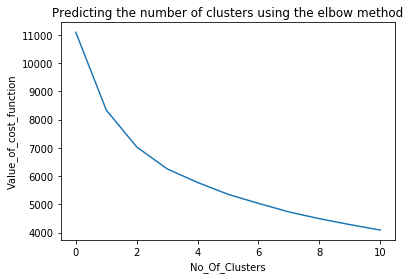

In [23]:
elb=[]
range_n_clusters=[2,3,4,5,6,7,8,9,10,11,12]
for num_clusters in range_n_clusters:
    kmeans=KMeans(n_clusters=num_clusters, max_iter=100)
    kmeans.fit(df_scaled)
    elb.append(kmeans.inertia_)
plt.plot(elb)
plt.title('Predicting the number of clusters using the elbow method')
plt.xlabel('No_Of_Clusters')
plt.ylabel('Value_of_cost_function')
plt.show()

In [33]:
%matplotlib notebook

Applying Kmeans clustering algorithmn

In [25]:
kmeans=KMeans(n_clusters=5, max_iter=50)
kmeans.fit(df_scaled)
l=kmeans.labels_
print(kmeans.labels_)

[3 3 1 ... 3 3 4]


In [26]:
df_scaled['Cluster_Id']=l
df_scaled

,Tempo,Valence,energy,acousticness,Cluster_Id
0,0.454842,0.239,0.200984,0.890562,3
1,0.270445,0.160,0.128982,0.941767,3
2,0.411715,0.559,0.588992,0.549197,1
3,0.265552,0.122,0.285986,0.860442,3
4,0.454413,0.441,0.211984,0.884538,3
...,...,...,...,...,...
86199,0.523224,0.297,0.672993,0.143574,0
86200,0.197827,0.890,0.017180,1.000000,3
86201,0.171757,0.386,0.033080,1.000000,3
86202,0.532915,0.211,0.517990,0.788153,3


Checking for the cluster centers for Tempo, Valence, Energy, Acousticness.

In [27]:
cluster_centers=kmeans.cluster_centers_
cluster_centers

array([[0.44969644, 0.32027581, 0.54254787, 0.2413491 ],
       [0.47549597, 0.71084422, 0.63214129, 0.54733143],
       [0.53033529, 0.37432232, 0.81647987, 0.05020667],
       [0.44485328, 0.30647995, 0.32675408, 0.79101628],
       [0.49466822, 0.76554281, 0.78337098, 0.10857253]])

Using Valance, Energy and acousticness since the centroids are optimally distributed.

In [35]:
a=cluster_centers[0]
a_attr_cent=a[3],a[1],a[2]

b=cluster_centers[1]
b_attr_cent=b[3],b[1],b[2]

c=cluster_centers[2]
c_attr_cent=c[3],c[1],c[2]

d=cluster_centers[3]
d_attr_cent=d[3],d[1],d[2]

e=cluster_centers[4]
e_attr_cent=e[3],e[1],e[2]

a_attr_cent

(0.24134909828898712, 0.32027580816607154, 0.5425478737608034)

Plotting the centroids of the clusters.

<IPython.core.display.Javascript object>


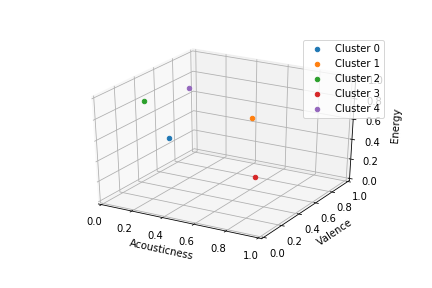

In [36]:
fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

axis.set_xlabel('Acousticness')
axis.set_ylabel('Valence')
axis.set_zlabel('Energy')

axis.scatter(a_attr_cent[0],a_attr_cent[1],a_attr_cent[2], label='Cluster 0')
axis.scatter(b_attr_cent[0],b_attr_cent[1],b_attr_cent[2], label='Cluster 1')
axis.scatter(c_attr_cent[0],c_attr_cent[1],c_attr_cent[2], label='Cluster 2')
axis.scatter(d_attr_cent[0],d_attr_cent[1],d_attr_cent[2], label='Cluster 3')
axis.scatter(e_attr_cent[0],e_attr_cent[1],e_attr_cent[2], label='Cluster 4')

plt.xlim(0,1)
plt.ylim(0,1)
axis.set_zlim(0,1)

axis.legend()
plt.show()

Plotting the graph for the different clusters

<IPython.core.display.Javascript object>


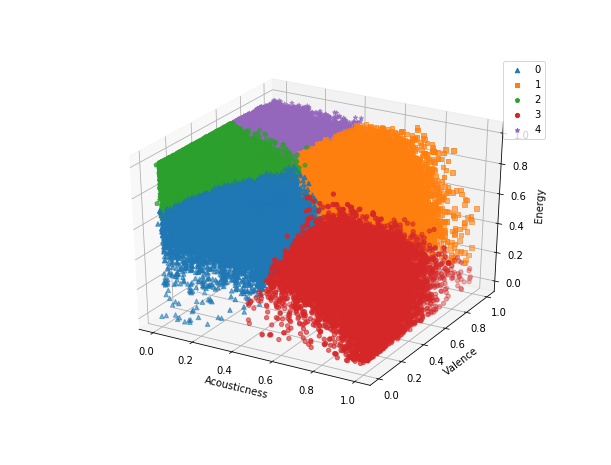

In [37]:



fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Acousticness')
axis.set_ylabel('Valence')
axis.set_zlabel('Energy')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.acousticness, group.Valence, group.energy, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

Plotting the graph for Tempo, Energy and Valence to check if the clusters are distributed equally.

<IPython.core.display.Javascript object>


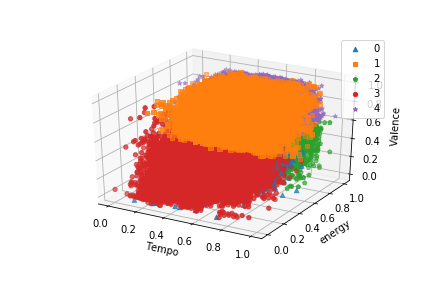

In [38]:


fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Tempo')
axis.set_ylabel('energy')
axis.set_zlabel('Valence')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.Tempo, group.energy, group.Valence, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

Plotting the graph for Tempo, Energy and Acousticness to check if the clusters are distributed equally.

<IPython.core.display.Javascript object>


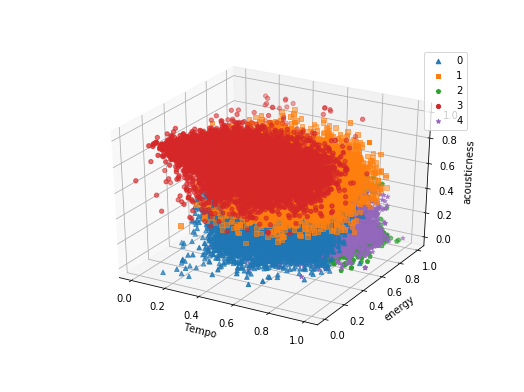

In [40]:

fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Tempo')
axis.set_ylabel('energy')
axis.set_zlabel('acousticness')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.Tempo, group.energy, group.acousticness, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

Plotting the graph for Tempo, Valence and Acousticness to check if the clusters are distributed equally.

<IPython.core.display.Javascript object>


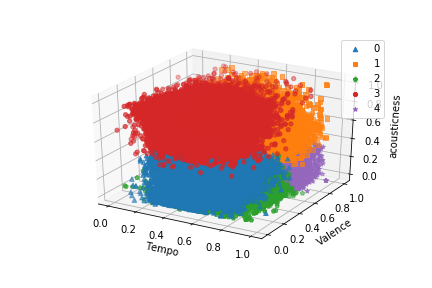

In [39]:
fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Tempo')
axis.set_ylabel('Valence')
axis.set_zlabel('acousticness')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.Tempo, group.Valence, group.acousticness, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

Appending the clusters into the dataframe 

In [41]:
df_scaled['id'] = df_final['id']
df_scaled

,Tempo,Valence,energy,acousticness,Cluster_Id,id
0,0.454842,0.239,0.200984,0.890562,3,1hx7X9cMXHWJjknb9O6Ava
1,0.270445,0.160,0.128982,0.941767,3,19oquvXf3bc65GSqtPYA5S
2,0.411715,0.559,0.588992,0.549197,1,4ODWgs1CVAZKDbryEodjiz
3,0.265552,0.122,0.285986,0.860442,3,0P5VfiSoLktD5N2nZDpQq0
4,0.454413,0.441,0.211984,0.884538,3,55qyghODi24yaDgKBI6lx0
...,...,...,...,...,...,...
86199,0.523224,0.297,0.672993,0.143574,0,0MmaEacabpK8Yp3Mdeo5uY
86200,0.197827,0.890,0.017180,1.000000,3,1dKxf4Ht2SsKLyXfSDJAgy
86201,0.171757,0.386,0.033080,1.000000,3,0SjsIzJkZfDU7wlcdklEFR
86202,0.532915,0.211,0.517990,0.788153,3,5rgu12WBIHQtvej2MdHSH0


Appending the artist names to the dataframe

In [43]:
artists_name =[]
for i in df_scaled.id:
    artists_name.append(data[data['id'] == i].artists.tolist())
    
df_scaled['artists'] = artists_name
df_scaled

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists
0,0.454842,0.239,0.200984,0.890562,3,1hx7X9cMXHWJjknb9O6Ava,[Frank Sinatra]
1,0.270445,0.160,0.128982,0.941767,3,19oquvXf3bc65GSqtPYA5S,[Frank Sinatra]
2,0.411715,0.559,0.588992,0.549197,1,4ODWgs1CVAZKDbryEodjiz,[Frank Sinatra]
3,0.265552,0.122,0.285986,0.860442,3,0P5VfiSoLktD5N2nZDpQq0,[Frank Sinatra]
4,0.454413,0.441,0.211984,0.884538,3,55qyghODi24yaDgKBI6lx0,[Joni Mitchell]
...,...,...,...,...,...,...,...
86199,0.523224,0.297,0.672993,0.143574,0,0MmaEacabpK8Yp3Mdeo5uY,[芝麻]
86200,0.197827,0.890,0.017180,1.000000,3,1dKxf4Ht2SsKLyXfSDJAgy,[Laureen Conrad]
86201,0.171757,0.386,0.033080,1.000000,3,0SjsIzJkZfDU7wlcdklEFR,[Gregory Oberle]
86202,0.532915,0.211,0.517990,0.788153,3,5rgu12WBIHQtvej2MdHSH0,[阿YueYue]


Appending the artist songs to the dataframe

In [44]:
song =[]
for i in df_scaled.id:
    song.append(data[data['id'] == i].name_x.tolist())
    
df_scaled['song'] = song
df_scaled

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song
0,0.454842,0.239,0.200984,0.890562,3,1hx7X9cMXHWJjknb9O6Ava,[Frank Sinatra],[The September Of My Years - Live At The Sands...
1,0.270445,0.160,0.128982,0.941767,3,19oquvXf3bc65GSqtPYA5S,[Frank Sinatra],[It Was A Very Good Year - Live At The Sands H...
2,0.411715,0.559,0.588992,0.549197,1,4ODWgs1CVAZKDbryEodjiz,[Frank Sinatra],"[Theme From New York, New York]"
3,0.265552,0.122,0.285986,0.860442,3,0P5VfiSoLktD5N2nZDpQq0,[Frank Sinatra],[It Was A Very Good Year]
4,0.454413,0.441,0.211984,0.884538,3,55qyghODi24yaDgKBI6lx0,[Joni Mitchell],"[The Circle Game - Live at The 2nd Fret, Phila..."
...,...,...,...,...,...,...,...,...
86199,0.523224,0.297,0.672993,0.143574,0,0MmaEacabpK8Yp3Mdeo5uY,[芝麻],[下雨天]
86200,0.197827,0.890,0.017180,1.000000,3,1dKxf4Ht2SsKLyXfSDJAgy,[Laureen Conrad],[The Cutest Puppy]
86201,0.171757,0.386,0.033080,1.000000,3,0SjsIzJkZfDU7wlcdklEFR,[Gregory Oberle],[John Brown's Song]
86202,0.532915,0.211,0.517990,0.788153,3,5rgu12WBIHQtvej2MdHSH0,[阿YueYue],[云与海]


In [54]:
clust_0 = df_scaled[df_scaled['Cluster_Id']==0]  
clust_0.sample(30)

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song
31405,0.538941,0.206,0.655993,0.359438,0,4UFlWyUXUots8pCHclBy9A,[Lissette],[Eclipse Total Del Amor (Total Eclipse of the ...
19807,0.477756,0.110,0.446989,0.111446,0,1W7zkKgRv9mrLbfdQ8XyH3,[Kehlani],[Gangsta]
34551,0.602355,0.379,0.607992,0.446787,0,4bEkPmsClXX6I7iawkhvqa,[Sexmane],[Starboy]
8286,0.520597,0.224,0.363987,0.451807,0,3CAX47TnPqTujLIQTw8nwI,[Ben Howard],[Old Pine]
23711,0.511785,0.418,0.499990,0.102410,0,2pyjbGTpJCPjMYwCbdymiF,[Ruel],[Dazed & Confused]
56887,0.321632,0.569,0.267985,0.124498,0,7tFrJ1JPTVmQKVU5XlGQdb,[Hers],[ยังคงคอย]
41252,0.369477,0.193,0.547991,0.002691,0,4aT9Pm5jhQBepwqyyuNbTT,[Gesaffelstein],[Opr]
80083,0.305692,0.177,0.476989,0.388554,0,3lYEuAi1KAXd9Jz1JUu43x,[Hasan],[Minulost]
86170,0.512860,0.183,0.546991,0.135542,0,6JbGxLSnazkU7f5KZyuUrm,[New Creation Worship],[Refuge]
53653,0.501718,0.270,0.696994,0.347390,0,6OUcBSlWDdg3t50Tngl71y,[Ukendt Kunstner],[Daglige Brød]


In [52]:
clust_1 = df_scaled[df_scaled['Cluster_Id']==1]  
clust_1.sample(30)

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song
83371,0.266034,0.885,0.617992,0.835341,1,03WNi94WYyEDEbaW53Cuel,[REVi],[KINISHINAI]
59535,0.379650,0.742,0.419988,0.418675,1,7poc2zkUJhN4EbSdtDOk0P,[Aiman JR],[Fresh Morocco]
84055,0.523356,0.967,0.855997,0.804217,1,6hJXgsa2Wy08Upx0MyEEE4,[Piosenki Szantowe],[Morskie Opowieści]
47088,0.231385,0.921,0.750995,0.583333,1,1japosZu7YrFMZcqeL9Z9J,[風格童星組合],[娃娃國]
63492,0.305687,0.721,0.505990,0.460843,1,2LqTFkL0PTNPmxituDxkDj,[Oldelaf],[La tristitude]
78566,0.379936,0.536,0.761995,0.548193,1,3KwRHlM7TwFRkpbHA3hK0v,[Majka & Pápai Joci],[Mikor a test örexik]
55140,0.321764,0.925,0.924998,0.579317,1,4XKTnUOoiKnOSAP0KuKhxK,[Maicol Benitez],[No Creia en el Amor]
66760,0.231665,0.908,0.261985,0.997992,1,6u8xlZtBbtELlLjrYj9fHw,[Matteo Bosi],[Preludio n.1 (Bach)]
32687,0.438299,0.871,0.638993,0.569277,1,4gGNitZelwNqNbMYnxPt7S,[Tuure Kilpeläinen ja Kaihon Karavaani],[Vaeltava aave]
39691,0.788855,0.642,0.675993,0.780120,1,5mDxt91vXGenhsLcCM9EYG,[Pantelis Pantelidis],[De Se Sighoro (Sto 'ha Pi)]


In [47]:
clust_2 = df_scaled[df_scaled['Cluster_Id'] == 2]
clust_2

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song
33,0.397396,0.497,0.836997,0.042169,2,3vhTPr9lvmerbruNCPTJBk,[Miles Davis],[Human Nature 2018 Edit]
38,0.507538,0.564,0.857997,0.125502,2,7l7vw9xdWTJLu0PQesQcaq,[The Yardbirds],[Happenings Ten Years Time Ago - Single A-Side]
46,0.501570,0.556,0.941999,0.090060,2,42A3B2pjAipXtpvfD8K3GZ,[Frankie Valli & The Four Seasons],[Working My Way Back to You]
48,0.501570,0.556,0.941999,0.090060,2,0fpqKUJC5NRRnb5AwuoeBF,[Frankie Valli & The Four Seasons],[Working My Way Back to You]
49,0.645551,0.567,0.790996,0.114458,2,2RWjugJQW9FQbQeun7CXav,[Frankie Valli & The Four Seasons],[The Night]
...,...,...,...,...,...,...,...,...
86175,0.533100,0.418,0.895998,0.270080,2,2OmArKXeh9feaFzyE4UOKh,[Stage and Theare Artists],[Will You]
86180,0.559287,0.344,0.688994,0.057831,2,4G3RE7nMKl4Yklg1aYCvPY,[Kelvin Tan],[就在這裡]
86181,0.734792,0.518,0.667993,0.147590,2,4OSl72bTia7Hrn8xfRKjbM,[Gen Neo],[Stop Sugar]
86188,0.512389,0.236,0.634993,0.031526,2,3QAsHztMu2rzflap6WJhps,[Shockwave],[Push]


In [46]:
clust_3 = df_scaled[df_scaled['Cluster_Id'] == 3]
clust_3

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song
0,0.454842,0.239,0.200984,0.890562,3,1hx7X9cMXHWJjknb9O6Ava,[Frank Sinatra],[The September Of My Years - Live At The Sands...
1,0.270445,0.160,0.128982,0.941767,3,19oquvXf3bc65GSqtPYA5S,[Frank Sinatra],[It Was A Very Good Year - Live At The Sands H...
3,0.265552,0.122,0.285986,0.860442,3,0P5VfiSoLktD5N2nZDpQq0,[Frank Sinatra],[It Was A Very Good Year]
4,0.454413,0.441,0.211984,0.884538,3,55qyghODi24yaDgKBI6lx0,[Joni Mitchell],"[The Circle Game - Live at The 2nd Fret, Phila..."
5,0.448016,0.299,0.183984,0.958835,3,00xemFYjQNRpOlPhVaLAHa,[Joni Mitchell],"[Urge For Going - Live at The 2nd Fret, Philad..."
...,...,...,...,...,...,...,...,...
86195,0.268501,0.362,0.464989,0.552209,3,7GRImTchCheEHqU3tong8Q,[风小筝],[别丢下我不管]
86198,0.564767,0.340,0.457989,0.763052,3,1PFGNasip0OTl24ZHPT6iy,[开开],[你一定要幸福]
86200,0.197827,0.890,0.017180,1.000000,3,1dKxf4Ht2SsKLyXfSDJAgy,[Laureen Conrad],[The Cutest Puppy]
86201,0.171757,0.386,0.033080,1.000000,3,0SjsIzJkZfDU7wlcdklEFR,[Gregory Oberle],[John Brown's Song]


In [50]:
clust_4 = df_scaled[df_scaled['Cluster_Id']==4]  
clust_4.sample(30)

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song
5967,0.475585,0.658,0.756995,0.002661,4,6LZaxlycSWrJZ4Volb25qx,[Taylor Swift],[Mine]
35811,0.629278,0.886,0.862997,0.130522,4,2W9GIZ2L9yTo3u3reabbdF,[Patrice Roberts],[Hit List]
66526,0.512617,0.730,0.848997,0.001596,4,3cO8w5kGXDdwQywhiX0G8J,[Good Charlotte],[Last Night]
8841,0.533465,0.862,0.986000,0.000005,4,6bBSHSMdjLgLYTwmwmwAd9,[Heatbeat],[It's Killing Me (Mix Cut) - Original Mix]
14462,0.522858,0.737,0.957999,0.000087,4,5wcRR1Za2OAN74YIddm8At,[Super8 & Tab],[L.A. (Mix Cut) - Original Mix]
18965,0.416809,0.737,0.551991,0.016566,4,3lIRSoJOt3wapE1QhgKqIo,[Mikis Theodorakis],[Otan Sfiggoun to Heri]
18671,0.554981,0.568,0.705994,0.070080,4,5vjix8dLoicfFmzgZBRCTS,[KALEO],[Fool]
35011,0.379878,0.692,0.439989,0.037651,4,5EKITWJXROxWdc0bcRrMLy,[SIX60],[Vibes]
29024,0.363986,0.666,0.875997,0.080422,4,1bc1ODVnWMraMz3y5X87r9,[Atiye],[Maazallah]
25376,0.756065,0.766,0.677993,0.007861,4,0w6N0Mb2fjxGUNtp3aabCN,[The Scene Is Now],[Bank]


In [55]:
genre=[]
for row in df_scaled.Cluster_Id:
    if row == 0:
        genre.append('Chill')
    elif row == 1:
        genre.append('Energetic')
    elif row == 2:
        genre.append('Groovy')
    elif row == 3:
        genre.append('Ballad')
    else:
        genre.append('Pop')

df_scaled['Genre'] = genre
df_scaled

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song,Genre
0,0.454842,0.239,0.200984,0.890562,3,1hx7X9cMXHWJjknb9O6Ava,[Frank Sinatra],[The September Of My Years - Live At The Sands...,Ballad
1,0.270445,0.160,0.128982,0.941767,3,19oquvXf3bc65GSqtPYA5S,[Frank Sinatra],[It Was A Very Good Year - Live At The Sands H...,Ballad
2,0.411715,0.559,0.588992,0.549197,1,4ODWgs1CVAZKDbryEodjiz,[Frank Sinatra],"[Theme From New York, New York]",Energetic
3,0.265552,0.122,0.285986,0.860442,3,0P5VfiSoLktD5N2nZDpQq0,[Frank Sinatra],[It Was A Very Good Year],Ballad
4,0.454413,0.441,0.211984,0.884538,3,55qyghODi24yaDgKBI6lx0,[Joni Mitchell],"[The Circle Game - Live at The 2nd Fret, Phila...",Ballad
...,...,...,...,...,...,...,...,...,...
86199,0.523224,0.297,0.672993,0.143574,0,0MmaEacabpK8Yp3Mdeo5uY,[芝麻],[下雨天],Chill
86200,0.197827,0.890,0.017180,1.000000,3,1dKxf4Ht2SsKLyXfSDJAgy,[Laureen Conrad],[The Cutest Puppy],Ballad
86201,0.171757,0.386,0.033080,1.000000,3,0SjsIzJkZfDU7wlcdklEFR,[Gregory Oberle],[John Brown's Song],Ballad
86202,0.532915,0.211,0.517990,0.788153,3,5rgu12WBIHQtvej2MdHSH0,[阿YueYue],[云与海],Ballad


In [59]:
df_scaled['artists'] = df_scaled['artists'].astype(str)

In [64]:
x= df_scaled[df_scaled['artists'] == "['Zakopower']"]
x

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song,Genre
83819,0.523007,0.717,0.656993,0.567269,1,2kcQMkj0nztimTpqWlVrof,['Zakopower'],[Boso],Energetic


In [65]:
x=data[data['artists'] == 'Zakopower']
x

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
83886,2kcQMkj0nztimTpqWlVrof,Boso,43,223385,0,Zakopower,7ipF6efgwi4IXIGUWDVN4d,2011-05-16,0.719,0.657,...,0.000003,0.343,0.717,130.025,4,2011,12600.0,"['classic polish pop', 'polish pop']",Zakopower,33


In [66]:
df_scaled[df_scaled['artists'] == "['Dua Lipa']"]

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song,Genre
18307,0.297601,0.368,0.650993,0.117470,0,1ixphys4A3NEXp6MDScfih,['Dua Lipa'],[Be the One],Chill
18308,0.410894,0.491,0.795996,0.018876,2,7kJlTKjNZVT26iwiDUVhRm,['Dua Lipa'],[Blow Your Mind (Mwah)],Groovy
18309,0.766661,0.324,0.264985,0.864458,3,7wIYDzWW82O6Rc4vGuzjND,['Dua Lipa'],"[I'm Not the Only One - Live from Spotify, Lon...",Ballad
18310,0.449123,0.608,0.699994,0.002620,4,2ekn2ttSfGqwhhate0LSR0,['Dua Lipa'],[New Rules],Pop
18311,0.348269,0.510,0.543991,0.040462,0,76cy1WJvNGJTj78UqeA5zr,['Dua Lipa'],[IDGAF],Chill
18312,0.490788,0.677,0.792996,0.012550,4,6WrI0LAC5M1Rw2MnX2ZvEg,['Dua Lipa'],[Don't Start Now],Pop
18313,0.490836,0.679,0.792996,0.012349,4,3PfIrDoz19wz7qK7tYeu62,['Dua Lipa'],[Don't Start Now],Pop
18314,0.432918,0.467,0.728995,0.167671,2,017PF4Q3l4DBUiWoXk4OWT,['Dua Lipa'],[Break My Heart],Groovy
18315,0.379968,0.914,0.883998,0.056325,4,39LLxExYz6ewLAcYrzQQyP,['Dua Lipa'],[Levitating],Pop
18316,0.612724,0.746,0.843997,0.013755,4,3AzjcOeAmA57TIOr9zF1ZW,['Dua Lipa'],[Physical],Pop


In [67]:
data[data['artists'] == 'Dua Lipa']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
18314,1ixphys4A3NEXp6MDScfih,Be the One,73,202915,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2015-10-30,0.661,0.651,...,0.000013,0.0560,0.368,87.460,4,2015,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18315,7kJlTKjNZVT26iwiDUVhRm,Blow Your Mind (Mwah),72,178583,1,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2016-08-26,0.654,0.796,...,0.000000,0.0948,0.491,108.854,4,2016,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18316,7wIYDzWW82O6Rc4vGuzjND,"I'm Not the Only One - Live from Spotify, London",68,195840,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2016-07-08,0.455,0.265,...,0.000000,0.6850,0.324,176.036,4,2016,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18317,2ekn2ttSfGqwhhate0LSR0,New Rules,82,209320,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2017-06-02,0.762,0.700,...,0.000016,0.1530,0.608,116.073,4,2017,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18318,76cy1WJvNGJTj78UqeA5zr,IDGAF,81,217947,1,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2017-06-02,0.836,0.544,...,0.000000,0.0824,0.510,97.028,4,2017,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18319,6WrI0LAC5M1Rw2MnX2ZvEg,Don't Start Now,86,183290,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2019-10-31,0.794,0.793,...,0.000000,0.0952,0.677,123.941,4,2019,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18320,3PfIrDoz19wz7qK7tYeu62,Don't Start Now,85,183290,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.793,0.793,...,0.000000,0.0951,0.679,123.950,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18321,017PF4Q3l4DBUiWoXk4OWT,Break My Heart,84,221820,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.730,0.729,...,0.000001,0.3490,0.467,113.013,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18322,39LLxExYz6ewLAcYrzQQyP,Levitating,82,203808,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.695,0.884,...,0.000000,0.2130,0.914,103.014,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18323,3AzjcOeAmA57TIOr9zF1ZW,Physical,79,193829,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.647,0.844,...,0.000658,0.1020,0.746,146.967,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95


In [72]:
df_scaled[df_scaled['artists'] == "['Thundercat']"]

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song,Genre
21487,0.266870,0.704,0.561991,0.542169,1,7CH99b2i1TXS5P8UUyWtnM,['Thundercat'],[Them Changes],Energetic
21488,0.575952,0.650,0.892998,0.830321,1,1c5CllrZr45UBhWpIqM332,['Thundercat'],[Funny Thing],Energetic


In [73]:
data[data['artists'] == 'Thundercat']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
21505,7CH99b2i1TXS5P8UUyWtnM,Them Changes,74,188454,0,Thundercat,4frXpPxQQZwbCu3eTGnZEw,2017-02-24,0.657,0.562,...,0.00143,0.101,0.704,81.657,4,2017,721390.0,"['afrofuturism', 'hip hop', 'indie soul']",Thundercat,73
21506,1c5CllrZr45UBhWpIqM332,Funny Thing,77,116630,0,Thundercat,4frXpPxQQZwbCu3eTGnZEw,2020-04-03,0.586,0.893,...,0.64200,0.212,0.650,140.023,3,2020,721390.0,"['afrofuturism', 'hip hop', 'indie soul']",Thundercat,73


In [74]:
df_scaled[df_scaled['artists'] == "['Good Charlotte']"]

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song,Genre
66525,0.422380,0.900,0.831997,0.014859,4,2wcDfk3TfQg3Jv8gEoTim7,['Good Charlotte'],[I Just Wanna Live],Pop
66526,0.512617,0.730,0.848997,0.001596,4,3cO8w5kGXDdwQywhiX0G8J,['Good Charlotte'],[Last Night],Pop
66527,0.416883,0.815,0.867997,0.008876,4,0AYw1CBLLNu0umIuCoq77M,['Good Charlotte'],[Like It's Her Birthday],Pop
66528,0.639218,0.867,0.814996,0.098896,4,5wJ0BL1beppAHQO3DtlEqh,['Good Charlotte'],[Sex On The Radio],Pop


In [75]:
data[data['artists'] == 'Good Charlotte']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
66587,2wcDfk3TfQg3Jv8gEoTim7,I Just Wanna Live,54,165947,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-11-12,0.804,0.832,...,0.0,0.1070,0.900,111.023,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71
66588,3cO8w5kGXDdwQywhiX0G8J,Last Night,50,220827,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-01-01,0.641,0.849,...,0.0,0.0418,0.730,128.063,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71
66589,0AYw1CBLLNu0umIuCoq77M,Like It's Her Birthday,51,210507,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-01-01,0.592,0.868,...,0.0,0.1440,0.815,109.985,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71
66590,5wJ0BL1beppAHQO3DtlEqh,Sex On The Radio,46,196587,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-01-01,0.548,0.815,...,0.0,0.0175,0.867,151.970,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71


In [76]:
df_scaled[df_scaled['artists'] == "['Flume']"]

,Tempo,Valence,energy,acousticness,Cluster_Id,id,artists,song,Genre
29394,0.311332,0.217,0.435989,0.170683,0,7e3tOlmiPgelgliAQPZYZd,['Flume'],[Holdin On],Chill
29395,0.310395,0.398,0.543991,0.396586,0,3ibA9LHADI12A3FHpeRx7Q,['Flume'],[Ezra],Chill
29396,0.311242,0.216,0.434989,0.175703,0,4s5652m7A8iuDQsZ0UWNcO,['Flume'],[Holdin On],Chill
29397,0.311332,0.217,0.435989,0.170683,0,3ohupB1Wm1Cvcyre7rtS9p,['Flume'],[Holdin On],Chill


In [77]:
data[data['artists'] == 'Flume']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
29420,7e3tOlmiPgelgliAQPZYZd,Holdin On,59,154414,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-09,0.430,0.436,...,0.000000,0.128,0.217,90.053,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
29421,3ibA9LHADI12A3FHpeRx7Q,Ezra,45,217188,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-09,0.582,0.544,...,0.006980,0.173,0.398,89.876,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
29422,4s5652m7A8iuDQsZ0UWNcO,Holdin On,55,154414,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-12,0.433,0.435,...,0.000002,0.128,0.216,90.036,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
29423,3ohupB1Wm1Cvcyre7rtS9p,Holdin On,55,154414,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-09,0.430,0.436,...,0.000000,0.128,0.217,90.053,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
